# Merchant 501 — Diwali target_base EDA & Reconciliation

## Step 1 — Load the dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

campaign = pd.read_csv("campaign.csv")
comm = pd.read_csv("communication_log.csv")

print("campaign:", campaign.shape)
print("communication_log:", comm.shape)


campaign: (7, 6)
communication_log: (30, 10)


In [2]:
campaign

,id,merchant_id,parent_id,name,creation_status,processing_status
0,9001,501,NaN,Diwali Cart Recovery - Wave 1,approved,processed
1,9002,501,9001.0,Diwali Cart Recovery - Retry A,approved,processed
2,9003,501,9002.0,Diwali Cart Recovery - Retry B,approved,processed
3,9004,501,9001.0,Diwali Cart Recovery - Retry C (pending),approval_awaiting,processed
4,9101,501,NaN,Diwali Flash Sale - Standalone,approved,processed
5,9201,501,NaN,Diwali Wave 2,approved,processed
6,9202,501,9201.0,Diwali Wave 2 - Retry,approved,processed


In [3]:
comm.head(10)

,id,merchant_id,communication_id,customer_id,communication_type,delivery_status,sent_time,scheduled_time,credit_used,channel
0,1,501,9001,C1,2,900,2026-10-03 10:00:00,2026-10-03 10:00:00,1,sms
1,2,501,9001,C2,2,1100,2026-10-03 10:00:00,2026-10-03 10:00:00,1,sms
2,3,501,9002,C2,2,900,2026-10-04 10:00:00,2026-10-04 10:00:00,1,sms
3,4,501,9001,C3,2,1100,2026-10-03 10:00:00,2026-10-03 10:00:00,1,sms
4,5,501,9002,C3,2,1100,2026-10-04 10:00:00,2026-10-04 10:00:00,1,sms
5,6,501,9003,C3,2,900,2026-10-05 10:00:00,2026-10-05 10:00:00,1,sms
6,7,501,9001,C4,2,900,2026-10-03 10:00:00,2026-10-03 10:00:00,1,sms
7,8,501,9001,C5,2,900,2026-10-03 10:00:00,2026-10-03 10:00:00,1,sms
8,9,501,9001,C6,2,900,2026-10-03 10:00:00,2026-10-03 10:00:00,1,sms
9,10,501,9001,C7,2,900,2026-10-03 10:00:00,2026-10-03 10:00:00,1,sms


## Step 2 — EDA: dtypes and null values

In [4]:
campaign.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 7 non-null      int64  
 1   merchant_id        7 non-null      int64  
 2   parent_id          4 non-null      float64
 3   name               7 non-null      str    
 4   creation_status    7 non-null      str    
 5   processing_status  7 non-null      str    
dtypes: float64(1), int64(2), str(3)
memory usage: 789.0 bytes


In [5]:
comm.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  30 non-null     int64
 1   merchant_id         30 non-null     int64
 2   communication_id    30 non-null     int64
 3   customer_id         30 non-null     str  
 4   communication_type  30 non-null     int64
 5   delivery_status     30 non-null     int64
 6   sent_time           30 non-null     str  
 7   scheduled_time      30 non-null     str  
 8   credit_used         30 non-null     int64
 9   channel             30 non-null     str  
dtypes: int64(6), str(4)
memory usage: 3.7 KB


In [6]:
print("Nulls in campaign:")
print(campaign.isna().sum())
print()
print("Nulls in communication_log:")
print(comm.isna().sum())


Nulls in campaign:
id                   0
merchant_id          0
parent_id            3
name                 0
creation_status      0
processing_status    0
dtype: int64

Nulls in communication_log:
id                    0
merchant_id           0
communication_id      0
customer_id           0
communication_type    0
delivery_status       0
sent_time             0
scheduled_time        0
credit_used           0
channel               0
dtype: int64


`campaign.parent_id` is the only column with real nulls — that's expected, it's null for the three top-level campaigns (`9001`, `9101`, `9201`) and populated for their retries. No nulls anywhere in `communication_log`.

## Step 3 — Campaign types & approval status

In [7]:
campaign[['creation_status','processing_status']].value_counts()

creation_status    processing_status
approved           processed            6
approval_awaiting  processed            1
Name: count, dtype: int64

## Step 4 — Delivery status codes: what do 900 / 1100 mean?

In [8]:
comm['delivery_status'].value_counts()

delivery_status
900     26
1100     4
Name: count, dtype: int64

In [9]:
merged = comm.merge(campaign, left_on='communication_id', right_on='id', suffixes=('_comm','_camp'))
merged[['communication_id','name','customer_id','delivery_status','sent_time','creation_status']].sort_values(['customer_id','sent_time'])

,communication_id,name,customer_id,delivery_status,sent_time,creation_status
0,9001,Diwali Cart Recovery - Wave 1,C1,900,2026-10-03 10:00:00,approved
12,9001,Diwali Cart Recovery - Wave 1,C10,900,2026-10-03 10:00:00,approved
13,9004,Diwali Cart Recovery - Retry C (pending),C11,900,2026-10-06 10:00:00,approval_awaiting
14,9004,Diwali Cart Recovery - Retry C (pending),C12,900,2026-10-06 10:00:00,approval_awaiting
15,9004,Diwali Cart Recovery - Retry C (pending),C13,900,2026-10-06 10:00:00,approval_awaiting
16,9004,Diwali Cart Recovery - Retry C (pending),C14,900,2026-10-06 10:00:00,approval_awaiting
1,9001,Diwali Cart Recovery - Wave 1,C2,1100,2026-10-03 10:00:00,approved
2,9002,Diwali Cart Recovery - Retry A,C2,900,2026-10-04 10:00:00,approved
17,9101,Diwali Flash Sale - Standalone,C20,900,2026-10-10 10:00:00,approved
18,9101,Diwali Flash Sale - Standalone,C20,900,2026-10-20 10:00:00,approved


Sorting by customer makes the pattern obvious. Look at customers who appear more than once, always inside a retry family:

| customer | 9001 (Wave 1) | 9002 (Retry A) | 9003 (Retry B) |
|---|---|---|---|
| C2 | 1100 (failed) | 900 (delivered) | — |
| C3 | 1100 (failed) | 1100 (failed) | 900 (delivered) |

Same shape for `D1`: `9201` → `1100` (failed), `9202` (its retry) → `900` (delivered).

**Mapping: `900` = delivered, `1100` = failed/undelivered.** Retry campaigns exist specifically to re-attempt customers whose previous send came back `1100`. `9004`'s customers (C11–C14) show `900` on the very first attempt — they aren't failure-retries at all, which is consistent with `9004` looking more like a new, not-yet-approved wave that got mislabeled/mis-processed than a genuine retry of failures.

In [10]:
# quick numeric confirmation of the failure->retry->success chains
chains = merged[merged['customer_id'].isin(['C2','C3','D1'])][['customer_id','communication_id','name','delivery_status','sent_time']]
chains.sort_values(['customer_id','sent_time'])

,customer_id,communication_id,name,delivery_status,sent_time
1,C2,9001,Diwali Cart Recovery - Wave 1,1100,2026-10-03 10:00:00
2,C2,9002,Diwali Cart Recovery - Retry A,900,2026-10-04 10:00:00
3,C3,9001,Diwali Cart Recovery - Wave 1,1100,2026-10-03 10:00:00
4,C3,9002,Diwali Cart Recovery - Retry A,1100,2026-10-04 10:00:00
5,C3,9003,Diwali Cart Recovery - Retry B,900,2026-10-05 10:00:00
24,D1,9201,Diwali Wave 2,1100,2026-10-07 10:00:00
25,D1,9202,Diwali Wave 2 - Retry,900,2026-10-08 10:00:00


## Step 5 — Duplicate sends (same campaign, same customer)

In [11]:
dupes = comm.groupby(['communication_id','customer_id']).size().reset_index(name='n').query('n > 1')
dupes

,communication_id,customer_id,n
17,9101,C20,2


In [12]:
comm[(comm.communication_id==9101) & (comm.customer_id=='C20')]

,id,merchant_id,communication_id,customer_id,communication_type,delivery_status,sent_time,scheduled_time,credit_used,channel
17,18,501,9101,C20,2,900,2026-10-10 10:00:00,2026-10-10 10:00:00,1,sms
18,19,501,9101,C20,2,900,2026-10-20 10:00:00,2026-10-20 10:00:00,1,sms


`C20` was sent twice under the **same, non-retry** campaign (`9101`), 10 days apart, both delivered (`900`).

## Step 6 — Visualizations

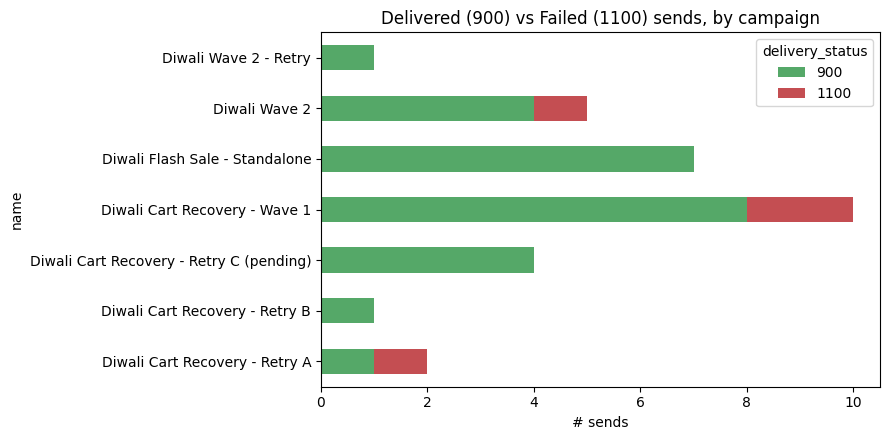

In [13]:
status_by_campaign = merged.pivot_table(
    index='name', columns='delivery_status', values='id_comm', aggfunc='count', fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4.5))
status_by_campaign.plot(kind='barh', stacked=True, ax=ax, color=['#55A868','#C44E52'])
ax.set_title('Delivered (900) vs Failed (1100) sends, by campaign')
ax.set_xlabel('# sends')
ax.legend(title='delivery_status')
plt.tight_layout()
plt.savefig('delivery_by_campaign.png', dpi=120)
plt.show()


The stacked bar makes the retry pattern visible at a glance: `Wave 1` and `Retry A` each carry some red (failed) volume that fully disappears by `Retry B`; `Wave 2` shows the same one-hop version with its retry. `Retry C (pending)` and `Flash Sale` show up as all-green (all delivered) with no failures — consistent with `Retry C` not actually being a failure-retry, and `Flash Sale` being a clean standalone send.